# Bring Your Own Target

**Turn the convex-cone reachability method into a one-call service for your own cell-state transition.**

You provide **one input**: a *target shift* — a vector `d` over genes describing where you want the
cell to move (which genes should go **up**, which should go **down**). The method answers, against a
*measured* perturbation-effect dictionary `E` (P perturbations × G genes):

| Question | What you get back |
|---|---|
| **Is the target reachable at all?** | A null-calibrated **verdict**: `reachable` / `partially reachable` / `weakly reachable` / `outside`. |
| **By knocking things down, or activating them?** | A signed **LOF / GOF-proxy / neither** decomposition — the measured knockdown share, the additional share matched by sign-flipped effects, and the remainder matched by neither. |
| **What exactly should I perturb?** | A ranked **knockdown recipe** (CRISPRi) *and* a ranked **activation recipe** (CRISPRa). |
| **How big a screen should I run next?** | The **optimal-k library** — the greedy reachability spectrum with the knee auto-detected. |
| **Where does knockdown fall short?** | An **unmet-readout ranking**: positive coordinates of the whole-vector Farkas residual that motivate CRISPRa or de-repression hypotheses. |

The engine is [`reachability.py`](../reachability.py); the effect dictionary here is the **Norman K562
CRISPRa** bundle (104 single perturbations × 2000 highly-variable genes). Everything below runs in **well
under two minutes** on a laptop — no GPU, no large download.

> **Geometric identity used throughout:** at the NNLS optimum the residual is orthogonal to the fit, so
> `reachable_cosine² + residual_norm² = 1`. The verdict is literally one right triangle.


In [1]:
# --- Setup: locate the repo, import the method, load the measured effect dictionary ---
import sys, time
from pathlib import Path
import numpy as np

def _find_repo(anchor="reachability.py"):
    """Walk upward from the current directory to find the repo root (holds reachability.py)."""
    here = Path.cwd().resolve()
    for base in (here, *here.parents):
        if (base / anchor).exists():
            return base
    raise FileNotFoundError(f"could not locate {anchor} above {here}")

REPO = _find_repo()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
import reachability as rx

BUNDLE = REPO / "notebooks" / "cache" / "norman_effect_bundle.npz"
b = np.load(BUNDLE, allow_pickle=True)

# RAW log-fold-change space (lfc_s / lfc_d), NOT the standardized Es/Ed (those are rank-deficient).
E             = b["lfc_s"].astype(float)                 # (104 x 2000) single-perturbation effect dictionary
lfc_d         = b["lfc_d"].astype(float)                 # (130 x 2000) measured DOUBLE perturbations (for the worked example)
pert_names    = [str(s) for s in b["sing_labels"]]       # length 104 — the perturbed gene for each row of E
doub_names    = [str(s) for s in b["doub_labels"]]       # length 130 — the double-perturbation labels
readout_names = [str(g) for g in b["genes_hvg"]]         # length 2000 — the readout gene axis
comp_idx      = b["comp_idx"]                            # (130 x 2) maps each double -> its two constituent singles
comp_ok       = b["comp_ok"]                             # (130,) bool: is this double cleanly decomposable?
gene_to_col   = {g: i for i, g in enumerate(readout_names)}

print(f"repo:            {REPO}")
print(f"effect matrix E: {E.shape}   (P={E.shape[0]} perturbations x G={E.shape[1]} readout genes)")
print(f"perturbations:   {pert_names[:6]} ...")
print(f"readout genes:   {readout_names[:6]} ...")

repo:            /Users/justin/Claude/Projects/Built with Claude/cell-state-reachability
effect matrix E: (104, 2000)   (P=104 perturbations x G=2000 readout genes)
perturbations:   ['AHR', 'ARID1A', 'ARRDC3', 'ATL1', 'BAK1', 'BCL2L11'] ...
readout genes:   ['FAM41C', 'RP11-54O7.1', 'RP11-54O7.3', 'SAMD11', 'ISG15', 'RNF223'] ...


## Define a target — two ways

### Way 1 — a worked example with a known answer

The cleanest way to see the method behave is to hand it a target we *already measured*: a **double
perturbation** from the Norman screen. Because a double `X+Y` is (approximately) the additive combination
of its two singles, a good method should (a) call it reachable and (b) recover **X** and **Y** as the top
recipe entries. We use `AHR+FEV`.

In [2]:
# Pick a measured double perturbation as the target d.
example_double = "AHR+FEV"
j = doub_names.index(example_double)
i1, i2 = int(comp_idx[j][0]), int(comp_idx[j][1])
d_example = lfc_d[j].copy()                      # target shift over the 2000 readout genes

print(f"target (worked example): {example_double}")
print(f"  = additive combination of singles: {pert_names[i1]} + {pert_names[i2]}")
print(f"  clean decomposition (comp_ok): {bool(comp_ok[j])}")
print(f"  ||d|| = {np.linalg.norm(d_example):.3f}   (nonzero over {int((d_example != 0).sum())} genes)")
print(f"  expected: 'reachable-ish', and {pert_names[i1]}/{pert_names[i2]} should top the knockdown recipe")

target (worked example): AHR+FEV
  = additive combination of singles: AHR + FEV
  clean decomposition (comp_ok): True
  ||d|| = 32.740   (nonzero over 1997 genes)
  expected: 'reachable-ish', and AHR/FEV should top the knockdown recipe


### Way 2 — paste your own signature

For your own target, supply a gene signature in **any** of three shapes and let the helper map it onto the
`readout_names` axis (zeros elsewhere):

- `weights={"GENE": desired_logFC, ...}` — signed magnitudes (positive = push **up**, negative = push **down**);
- `up=[...] , down=[...]` — just lists of genes to move, with a uniform magnitude;
- a mix of both.

**Guardrails.** Gene matching is case-insensitive; genes not on the readout axis are reported and skipped
(they can't constrain a fit); an all-zero target raises rather than silently returning a meaningless verdict.
Only genes present in `readout_names` (the 2000 HVGs) can participate — this is a *basis-specific* method.

In [3]:
def signature_to_target(readout_names, gene_to_col, *, weights=None, up=None, down=None,
                         up_value=1.0, down_value=1.0, verbose=True):
    """Map a human gene signature onto the readout axis -> a target vector d (len G, zeros elsewhere).

    weights : {gene: signed_logFC}   up>0, down<0
    up/down : lists of gene names moved by +up_value / -down_value
    Matching is case-insensitive; genes absent from readout_names are reported and skipped.
    """
    G = len(readout_names)
    d = np.zeros(G, dtype=float)
    upper = {g.upper(): i for g, i in gene_to_col.items()}
    missing, mapped = [], 0

    def _set(gene, val):
        nonlocal mapped
        i = gene_to_col.get(gene, upper.get(str(gene).upper()))
        if i is None:
            missing.append(gene); return
        d[i] = val; mapped += 1

    for g, v in (weights or {}).items(): _set(g, float(v))
    for g in (up or []):                 _set(g, +abs(up_value))
    for g in (down or []):               _set(g, -abs(down_value))

    if verbose:
        print(f"  mapped {mapped}/{len(up or []) + len(down or []) + len(weights or {})} "
              f"signature genes onto the {G}-gene readout axis;  ||d|| = {np.linalg.norm(d):.3f}")
        if missing:
            print(f"  SKIPPED (not in the 2000-gene readout basis): {missing}")
    if mapped == 0:
        raise ValueError("no signature gene matched the readout axis - nothing to fit")
    return d

# --- demo signature (edit these to describe YOUR target) --------------------------------
# A toy "toward-erythroid / away-from-myeloid" shift, expressed in genes on the readout axis.
# 'NOTAGENE1' is included on purpose to show the guardrail reporting (and skipping) an off-axis gene.
d_custom = signature_to_target(
    readout_names, gene_to_col,
    up   =["KLF1", "CEBPE"],                 # push UP
    down =["SPI1", "JUN", "FOS"],            # push DOWN
    weights={"CEBPA": -1.5, "NOTAGENE1": 2.0},
)

  mapped 6/7 signature genes onto the 2000-gene readout axis;  ||d|| = 2.693
  SKIPPED (not in the 2000-gene readout basis): ['NOTAGENE1']


## Run the design

Choose which target to design against. We run the **worked example** (`d_example`) so the output is
reproducible and its correctness is easy to check; swap in `d_custom` (or your own vector) on the next line
to design against your signature.

In [4]:
# Choose the target here:  d = d_example  (worked example)  |  d = d_custom  (your signature)
d = d_example

t0 = time.time()
res = rx.design_experiment(
    E, d,
    perturbation_names=pert_names,
    readout_names=readout_names,
    k_max=10, top=15,
    n_shuffles=10,          # small held-out-null so the notebook returns in ~seconds
    cert_top=15, seed=0,
)
elapsed = time.time() - t0
print(f"design_experiment finished in {elapsed:.2f} s\n")
print(res.summary())

design_experiment finished in 0.03 s

[PARTIALLY REACHABLE] reach_cos=0.853 (held-out 0.858, z=29.3)  LOF=0.73/GOF=0.01/neither=0.26  optimal_k=2


### The design card

In [5]:
def print_design_card(res):
    """Pretty-print a DesignResult as a researcher-facing design card."""
    line = "-" * 78
    print(line)
    print(f"VERDICT: {res.verdict.upper():<20}"
          f"(null-calibrated: {res.null_calibrated})")
    print(line)

    print("GEOMETRY (right triangle: reachable_cosine^2 + residual_norm^2 = 1)")
    print(f"  reachable_cosine (knockdown reach) : {res.reachable_cosine:6.3f}")
    print(f"  signed_cosine    (LOF+GOF reach)   : {res.signed_cosine:6.3f}")
    print(f"  residual_norm    (unreached share) : {res.residual_norm:6.3f}")
    check = res.reachable_cosine**2 + res.residual_norm**2
    print(f"  identity check   (should be 1.000) : {check:6.3f}")
    print(f"  held-out cosine  (honest / de-biased): {res.held_out_cosine:6.3f}"
          f"   (z = {res.held_out_z:.1f} vs shuffled-target null)")

    print("\nMODALITY DECOMPOSITION (share of the target norm)")
    print(f"  reachable by KNOCKDOWN (LOF)  : {res.lof_fraction:6.1%}")
    print(f"  matched by sign-flipped GOF proxy : {res.gof_fraction:6.1%}")
    print(f"  matched by NEITHER                 : {res.neither_fraction:6.1%}")

    print(f"\nKNOCKDOWN RECIPE (CRISPRi) - top {min(len(res.knockdown_recipe),10)} of "
          f"{res.n_knockdown_support} support genes")
    for r in res.knockdown_recipe[:10]:
        print(f"  {r['rank']:>2}. {r['gene']:<12} weight={r['weight']:.3f}")

    print(f"\nACTIVATION RECIPE (CRISPRa) - top {min(len(res.activation_recipe),10)} of "
          f"{res.n_activation_support} support genes")
    for r in res.activation_recipe[:10]:
        print(f"  {r['rank']:>2}. {r['gene']:<12} weight={r['weight']:.3f}")

    print(f"\nOPTIMAL NEXT-SCREEN LIBRARY  (auto-detected knee: optimal_k = {res.optimal_k})")
    print(f"  {'k':>2}  {'gene added':<12} {'cosine@k':>9}  {'marginal':>9}")
    for lib in res.library:
        star = "  <- knee" if lib["k"] == res.optimal_k else ""
        print(f"  {lib['k']:>2}  {str(lib['gene']):<12} {lib['cosine_at_k']:9.3f}  "
              f"{lib['marginal_gain']:9.3f}{star}")

    print(f"\nUNMET-READOUT HYPOTHESES  (positive coordinates of the full residual)")
    print(f"  KKT optimality violation (should be ~0): {res.cert_max_violation:.2e}")
    print(f"  {'gene':<12} {'residual':>9} {'target':>9}")
    for c in res.activation_certificate[:10]:
        print(f"  {str(c['gene']):<12} {c['residual']:9.3f} {c['target']:9.3f}")
    print(line)

print_design_card(res)

------------------------------------------------------------------------------
VERDICT: PARTIALLY REACHABLE (null-calibrated: True)
------------------------------------------------------------------------------
GEOMETRY (right triangle: reachable_cosine^2 + residual_norm^2 = 1)
  reachable_cosine (knockdown reach) :  0.853
  signed_cosine    (LOF+GOF reach)   :  0.861
  residual_norm    (unreached share) :  0.522
  identity check   (should be 1.000) :  1.000
  held-out cosine  (honest / de-biased):  0.858   (z = 29.3 vs shuffled-target null)

MODALITY DECOMPOSITION (share of the target norm)
  reachable by KNOCKDOWN (LOF)  :  72.7%
  matched by sign-flipped GOF proxy :   1.3%
  matched by NEITHER                 :  26.0%

KNOCKDOWN RECIPE (CRISPRi) - top 10 of 35 support genes
   1. AHR          weight=0.720
   2. FEV          weight=0.683
   3. MAP2K6       weight=0.076
   4. COL2A1       weight=0.063
   5. S1PR2        weight=0.062
   6. SNAI1        weight=0.060
   7. HES7         w

### The reachability spectrum

How much of the target does the *best k-perturbation subset* reach, as a function of `k`? The knee
(`optimal_k`) is the point of diminishing returns — a principled size for the next screen.

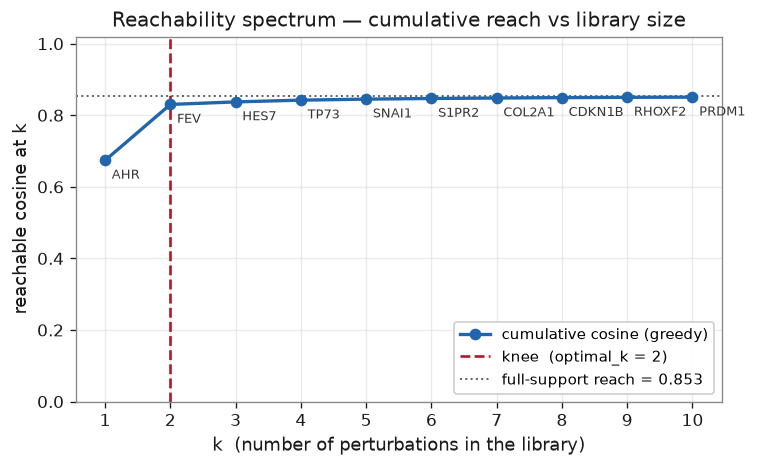

In [6]:
import io
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

spec = res.spectrum
ks   = np.asarray(spec["k"], dtype=int)
cos  = np.asarray(spec["cosine"], dtype=float)

fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.plot(ks, cos, "-o", color="#2166ac", lw=2, ms=6, zorder=3, label="cumulative cosine (greedy)")
ax.axvline(res.optimal_k, color="#b2182b", ls="--", lw=1.6, zorder=2,
           label=f"knee  (optimal_k = {res.optimal_k})")
ax.axhline(res.reachable_cosine, color="#666666", ls=":", lw=1.2, zorder=1,
           label=f"full-support reach = {res.reachable_cosine:.3f}")

# annotate the gene added at each step
order = list(spec["order"])
for k, c, gi in zip(ks, cos, order):
    name = pert_names[int(gi)] if int(gi) < len(pert_names) else str(gi)
    ax.annotate(name, (k, c), textcoords="offset points", xytext=(4, -11),
                fontsize=7.5, color="#333333", rotation=0)

ax.set_xlabel("k  (number of perturbations in the library)", fontsize=11, color="#1a1a1a")
ax.set_ylabel("reachable cosine at k", fontsize=11, color="#1a1a1a")
ax.set_title("Reachability spectrum — cumulative reach vs library size",
             fontsize=12, color="#1a1a1a")
ax.set_ylim(0, 1.02)
ax.set_xticks(ks)
ax.grid(alpha=0.25)
ax.legend(loc="lower right", fontsize=9, framealpha=0.95)
ax.tick_params(colors="#1a1a1a")
for spine in ax.spines.values():
    spine.set_edgecolor("#888888")
fig.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
plt.close(fig)
display(Image(data=buf.getvalue()))

## Honest caveats — read before you order oligos

1. **Activation-certificate genes are *hypotheses*, not orders.** The method approximates activation of a
   gene by the sign-flip of its measured knockdown effect. A certificate gene may be a **negative
   regulator** — activating its *repressor* (or knocking the gene down) could be what actually moves the
   target. **Check the sign at the bench.**
2. **The recipe is basis-specific.** Weights are expressed in *this* effect dictionary's perturbation and
   gene basis (Norman K562, 2000 HVGs). Recipes transfer *direction* across cell types better than they
   transfer *magnitude* — re-fit on your own measured `E` before trusting the exact weights.
3. **Absolute cosine is modest, and that's expected.** A partially-reachable verdict with `cos ≈ 0.5–0.85`
   is the normal regime for real biology — knockdown removes programs more easily than it installs them.
   Read the **held-out cosine** (de-biased) and the **z vs the shuffled-target null**, not the in-sample
   number alone.
4. **Only genes on the readout axis participate.** A signature gene absent from `readout_names` is silently
   dropped (the helper reports it). If most of your signature lives off-axis, the verdict is about the
   *on-axis remainder*, not your full intent.
5. **`n_shuffles` is small here (10) for speed.** For a publication-grade null, raise it (e.g. 200+); the
   verdict thresholds are unchanged but the z-score stabilises.

---
*Engine: `reachability.py` · effect dictionary: Norman K562 CRISPRa (104 × 2000) · runs in < 2 min, CPU-only.*
